In [24]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from cns.data_utils import  save_cns_fig, main_load
from cns.utils import find_knee, count_cum_val

In [26]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (6, 6), 'figure.dpi': 100})	

In [27]:
data = main_load(use_filter=False, concat=False)[0]
# rename key TCGA_hg19 to TCGA
data["TCGA"] = data["TCGA_hg19"]
del data["TCGA_hg19"]
data["combined"] = main_load(use_filter=False, concat=True)[0]
datasets = list(data.keys())
print(datasets)
colors = {"PCAWG": "C0", "TCGA": "C1", "TRACERx": "C2", "combined": "gray"}

['PCAWG', 'TRACERx', 'TCGA', 'combined']


PCAWG fitered 3
TRACERx fitered 19
TCGA fitered 16
combined fitered 352


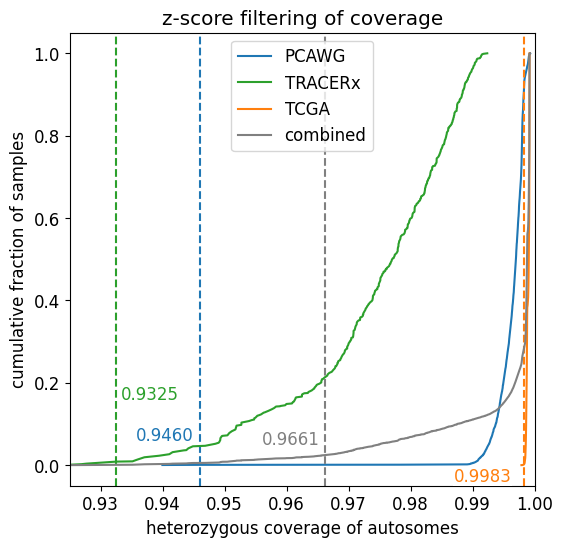

In [28]:
feature = "cover_het_aut"   
min_val = 0.925
outliers = {}
offsets = { "PCAWG": (-0.001, 0.05), "TCGA": (-0.002, -0.05), "TRACERx": (+0.01, 0.15), "combined": (-0.00075, 0.04)}	
for k in datasets:
    X, Y = count_cum_val(data[k][feature], min_val=min_val)
    plt.plot(X, Y, label=k, color=colors[k])   
    selection = data[k][feature]
    # calculate the z-score for selection
    z = (selection - selection.mean()) / selection.std()
    filter = z[(z < -3)]
    outliers[k] = data[k].loc[filter.index]
    print(k, "fitered", len(outliers[k]))
    x_pos = outliers[k][feature].max()
    plt.axvline(x_pos, color=colors[k], linestyle="--")
    plt.text(
        x_pos + offsets[k][0], 
        offsets[k][1], 
        f"{x_pos:.4f}", 
        color=colors[k], 
        verticalalignment='bottom', 
        horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='none', pad=.3)
    )

plt.xlim(min_val, 1)
plt.xlabel("heterozygous coverage of autosomes")
plt.ylabel("cumulative fraction of samples")
plt.legend()
plt.title(f"z-score filtering of coverage")
save_cns_fig(f"fig_samples_coverage_fraction_zscore")

PCAWG filtered 28
PCAWG below [('SP107557', 0.5766912308706281)]
TRACERx filtered 89
TCGA filtered 269
combined filtered 1927
combined below [('SP107557', 0.5766912308706281)]


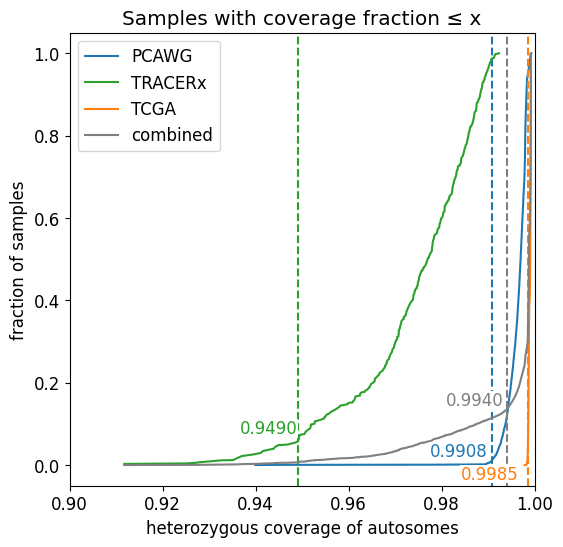

In [29]:
feature = "cover_het_aut"   
min_val = 0.90
offsets = { "PCAWG": (-0.001, 0.000), "TCGA": (-0.002, -0.07), "TRACERx": (+0.0000, 0.01), "combined": (-0.00075, 0.0)}	
for k in datasets:
    X, Y = count_cum_val(data[k][feature], min_val=min_val)
    below = data[k][feature][data[k][feature] < min_val]

    knee_index, knee_value = find_knee(X, Y, knee=False)
    if knee_index < 0:
        continue
    print(k, "filtered", sum(data[k][feature] <= X[knee_index]))
    x_pos = X[knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--")
    plt.text(
        x_pos + offsets[k][0], 
        Y[knee_index] + offsets[k][1], 
        f"{x_pos:.4f}", 
        color=colors[k], 
        verticalalignment='bottom', 
        horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='none', pad=.3)
    )

    if (len(below) > 0):
        print(k, "below", list(zip(below.index.values, below.values)))
    plt.plot(X, Y, label=k, color=colors[k])    

plt.xlim(min_val, 1)
plt.xlabel("heterozygous coverage of autosomes")
plt.ylabel("fraction of samples")
plt.legend()
plt.title(f"Samples with coverage fraction ≤ x")
save_cns_fig(f"fig_samples_coverage_fraction_knee")

PCAWG filtered 211 is 0.08168795973674023
TCGA filtered 745 is 0.07471667836726507
combined filtered 965 is 0.06808240440242698


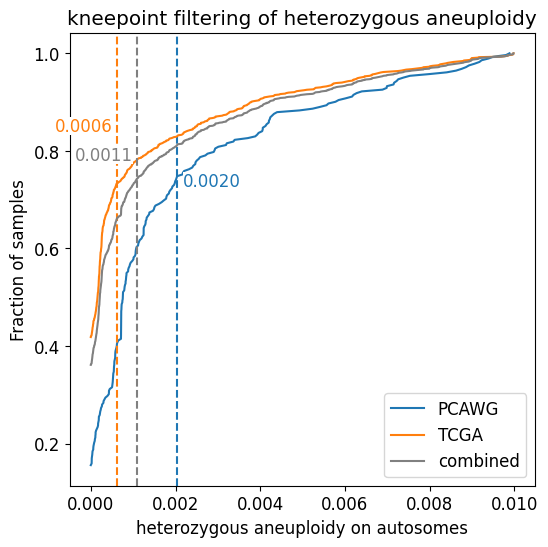

In [30]:
feature = "ane_het_aut"
offsets = {"PCAWG": (0.0015, -0.03), "TCGA": (-0.0001, 0.1), "TRACERx": (+0.0000, 0.01), "combined": (-0.0001, 0.03)}
for k in datasets:
    X, Y = count_cum_val(data[k][feature], max_val=0.01)
    knee_index, knee_value = find_knee(X, Y, knee=True)
    if knee_index < 0:
        continue
    plt.plot(X, Y, label=k, color=colors[k])
    filtered = sum(data[k][feature] <= X[knee_index])
    print(k, "filtered", filtered, "is", filtered / len(data[k]))
    x_pos = X[knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--")
    plt.text(
        x_pos + offsets[k][0],
        Y[knee_index] + offsets[k][1],
        f"{x_pos:.4f}",
        color=colors[k],
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(facecolor="white", edgecolor="none", pad=0.3),
    )

plt.xlabel("heterozygous aneuploidy on autosomes")
plt.ylabel("Fraction of samples")
plt.title(f"kneepoint filtering of heterozygous aneuploidy")
plt.legend()
save_cns_fig(fig_name=f"fig_samples_imbalance_fraction")

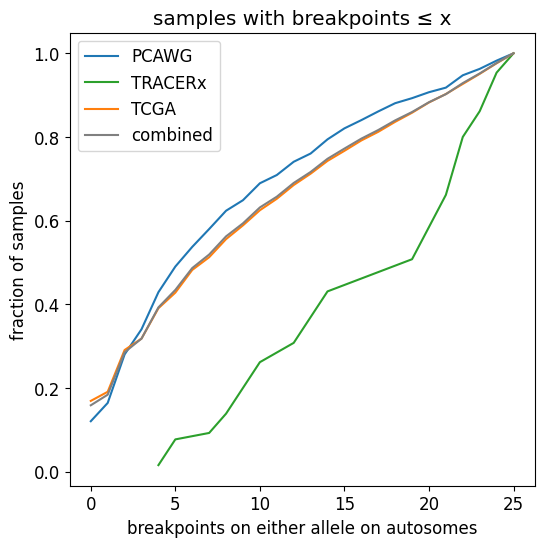

In [31]:
feature = "breaks_total_cn_aut"   
for k in datasets:
    X, Y = count_cum_val(data[k][feature], max_val=25)
    plt.plot(X, Y, label=k, color=colors[k])    

plt.ylabel("fraction of samples")
plt.xlabel("breakpoints on either allele on autosomes")
plt.title(f"samples with breakpoints ≤ x")
plt.legend()
save_cns_fig(f"fig_samples_breakpoints")

# Full plots

In [32]:
def plot_feature(feature, label, data, min_val=None, max_val=None):
    min_val = np.min([np.min(v[feature]) for v in data.values()]) if min_val is None else min_val
    max_val = np.max([np.max(v[feature]) for v in data.values()]) if max_val is None else max_val
    for k, v in data.items():
        X, Y = count_cum_val(v[feature], min_val, max_val)    
        plt.plot(X, Y, label=k, color=colors[k])    
        
    plt.xlabel(f"{label}")
    plt.ylabel("fraction of samples")
    plt.legend()
    plt.title(f"samples with {label} ≤ x")    

In [33]:
data["combined"].columns

Index(['sex', 'type', 'histology_tier2', 'TCGA_id', 'TCGA_type', 'chrom_count',
       'chrom_missing', 'cover_het_aut', 'cover_het_sex', 'cover_het_all',
       'cover_hom_aut', 'cover_hom_sex', 'cover_hom_all', 'ane_het_aut',
       'ane_het_sex', 'ane_het_all', 'loh_hom_aut', 'loh_hom_sex',
       'loh_hom_all', 'loh_het_aut', 'loh_het_sex', 'loh_het_all',
       'ane_hom_aut', 'ane_hom_sex', 'ane_hom_all', 'imb_major_cn_aut',
       'imb_major_cn_sex', 'imb_major_cn_all', 'imb_minor_cn_aut',
       'imb_minor_cn_sex', 'imb_minor_cn_all', 'ploidy_major_cn',
       'ploidy_minor_cn', 'breaks_major_cn_aut', 'breaks_major_cn_sex',
       'breaks_major_cn_all', 'step_major_cn_aut', 'step_major_cn_sex',
       'step_major_cn_all', 'breaks_minor_cn_aut', 'breaks_minor_cn_sex',
       'breaks_minor_cn_all', 'step_minor_cn_aut', 'step_minor_cn_sex',
       'step_minor_cn_all', 'breaks_total_cn_aut', 'breaks_total_cn_sex',
       'breaks_total_cn_all', 'step_total_cn_aut', 'step_total_cn_sex

In [34]:
print(data["combined"].query("cover_het_sex > 1")[["sex", "type"]])

Empty DataFrame
Columns: [sex, type]
Index: []


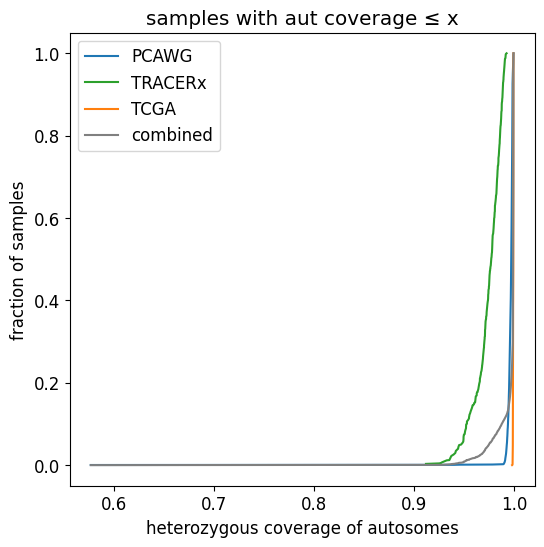

In [35]:
feature = "cover_het_aut"
plot_feature(feature, "aut coverage", data)
plt.xlabel("heterozygous coverage of autosomes")
save_cns_fig(f"fig_samples_{feature}")

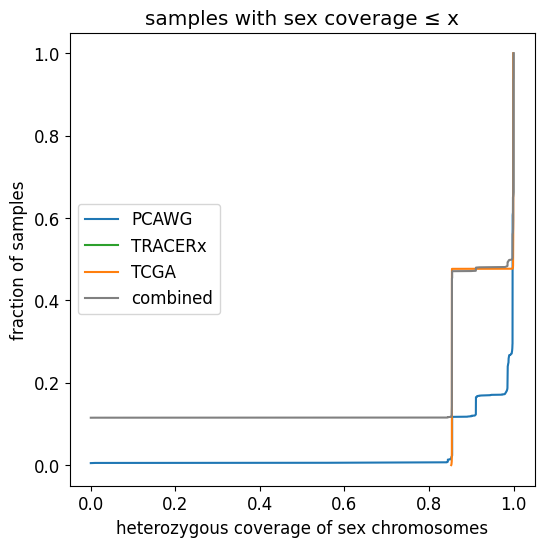

In [36]:
feature = "cover_het_sex"
plot_feature(feature, "sex coverage", data)
plt.xlabel("heterozygous coverage of sex chromosomes")
save_cns_fig(f"fig_samples_{feature}")

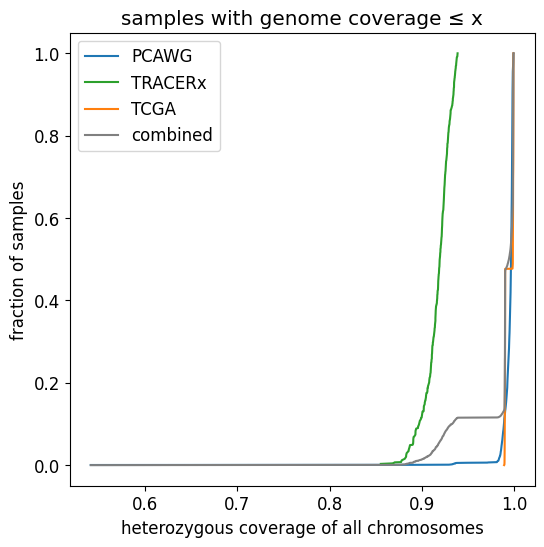

In [37]:
feature = "cover_hom_all"
plot_feature(feature, "genome coverage", data)
plt.xlabel("heterozygous coverage of all chromosomes")
save_cns_fig(f"fig_samples_{feature}")

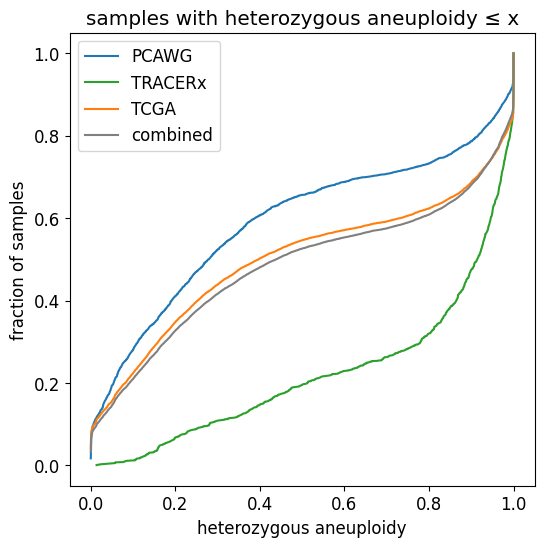

In [38]:
feature = "ane_het_aut"
plot_feature(feature, "heterozygous aneuploidy", data)
plt.xlabel("heterozygous aneuploidy")
save_cns_fig(f"fig_samples_{feature}")

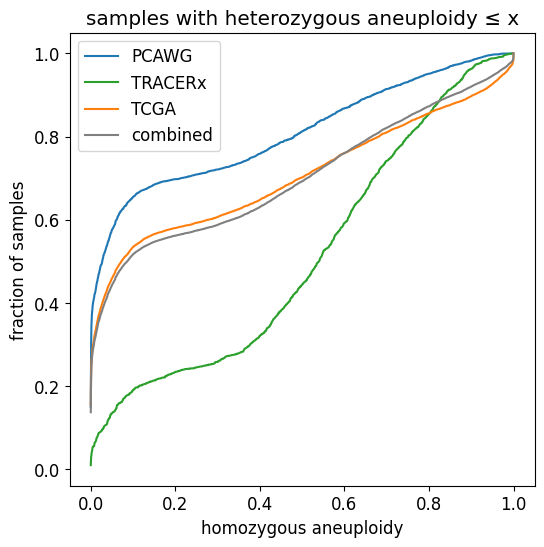

In [39]:
feature = "ane_hom_aut"
plot_feature(feature, "heterozygous aneuploidy", data)
plt.xlabel("homozygous aneuploidy")
save_cns_fig(f"fig_samples_{feature}")

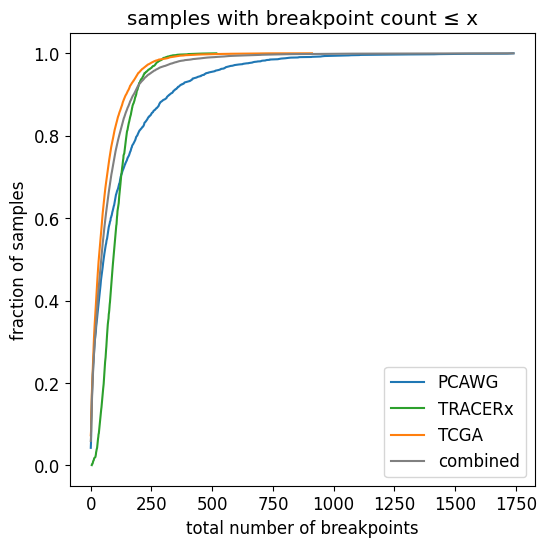

In [40]:
feature = "breaks_total_cn_aut"
plot_feature(feature, "breakpoint count", data)
plt.xlabel("total number of breakpoints")
save_cns_fig(f"fig_samples_{feature}")

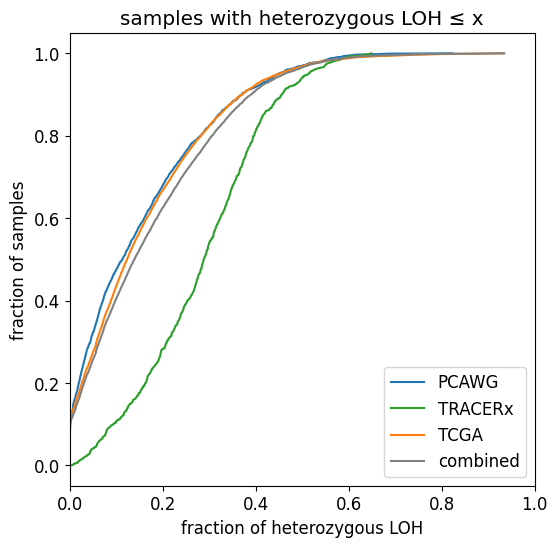

In [41]:
feature = "loh_het_aut"
plot_feature(feature, "heterozygous LOH", data)
plt.xlim(0,1)
plt.xlabel("fraction of heterozygous LOH")
save_cns_fig(f"fig_samples_{feature}")

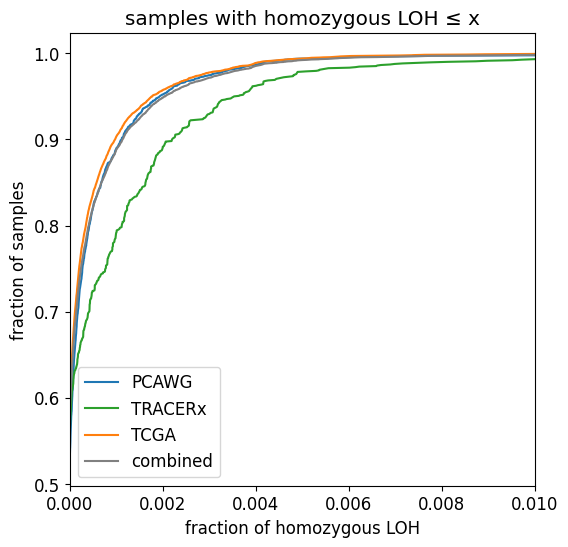

In [42]:
feature = "loh_hom_aut"
plot_feature(feature, "homozygous LOH", data)
plt.xlim(0,0.01)
plt.xlabel("fraction of homozygous LOH")
save_cns_fig(f"fig_samples_{feature}")

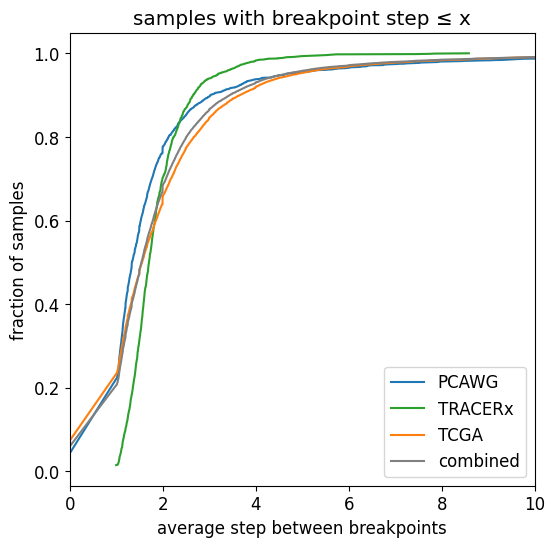

In [43]:
feature = "step_total_cn_aut"
plot_feature(feature, "breakpoint step", data)
plt.xlim(0, 10)
plt.xlabel("average step between breakpoints")
save_cns_fig(f"fig_samples_{feature}")


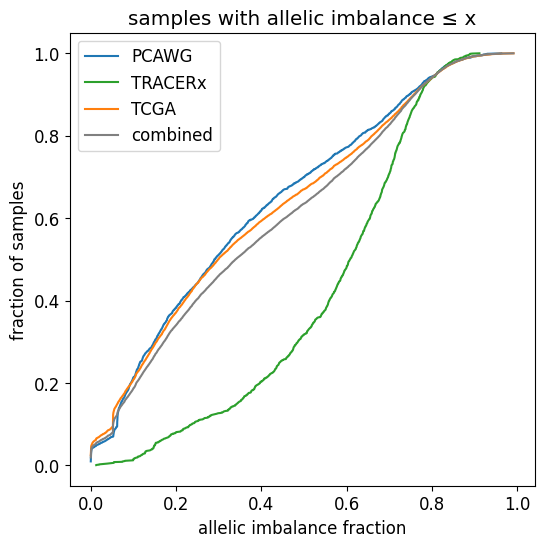

In [45]:
feature = "imb_major_cn_all"
plot_feature(feature, "allelic imbalance", data)
plt.xlabel("allelic imbalance fraction")
save_cns_fig(f"fig_samples_{feature}")